## EDA - meetup.com Data from Kaggle

### Imports and Data Download

In [1]:
# General
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import OneHotEncoder

# Data download
import kagglehub
import shutil

# Plotting 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Specific to network purposes
import networkx as nx

In [283]:
downloaded_path = kagglehub.dataset_download("stkbailey/nashville-meetup")
dest_path = "data/raw/"
os.makedirs(os.path.dirname(dest_path), exist_ok=True)

shutil.copytree(downloaded_path, dest_path, dirs_exist_ok=True)
print(f"Dataset moved to: {dest_path}")

Dataset moved to: data/raw/


In [284]:
data_dir = 'data/raw/'

# The files 
files_to_check = [
    'meta-events.csv',
    'meta-groups.csv',
    'meta-members.csv',
    'rsvps.csv',
    'member-to-group-edges.csv',
    'member-edges.csv',
    'group-edges.csv'
]

for file in files_to_check:
    file_path = os.path.join(data_dir, file)
    if os.path.exists(file_path):
        print(f"========== {file} ==========")
        # Read first 3 rows
        df = pd.read_csv(file_path, nrows=3)
        print(f"COLUMNS: {df.columns.tolist()}\n")
        print(df)
        print("\n")
    else:
        print(f"========== {file} NOT FOUND ==========\n")

========== meta-events.csv ==========
COLUMNS: ['event_id', 'group_id', 'name', 'time']

       event_id  group_id                                               name  \
0     243930425  26140018  2017 Nashville Walk to End Alzheimers - Octob...   
1     244208851  25604533                          Steak Dinner on the Patio   
2  pxlktnywnbfb  25973656                                    Schedule Meetup   

                  time  
0  2017-10-14 12:00:00  
1  2017-10-15 00:15:00  
2  2017-10-03 23:30:00  


========== meta-groups.csv ==========
COLUMNS: ['group_id', 'group_name', 'num_members', 'category_id', 'category_name', 'organizer_id', 'group_urlname']

   group_id                        group_name  num_members  category_id  \
0    339011           Nashville Hiking Meetup        15838           23   
1  19728145  Stepping Out Social Dance Meetup         1778            5   
2   6335372                  Nashville soccer         2869           32   

          category_name  organiz

### Data Processing and Cleaning

- Handle missing values and duplicates

- One-hot encode categorical variables

- Normalization/scaling?

In [285]:
# Load data (dropping the artifact 'Unnamed: 0' columns immediately)
events_df = pd.read_csv(os.path.join(data_dir, 'meta-events.csv'))
groups_df = pd.read_csv(os.path.join(data_dir, 'meta-groups.csv'))
mem_df = pd.read_csv(os.path.join(data_dir, 'meta-members.csv'), index_col='member_id') # Index col setting attribution: Stephen Bailey
rsvps_df = pd.read_csv(os.path.join(data_dir, 'rsvps.csv')).drop(columns=['Unnamed: 0'], errors='ignore')
mem_grp_edges = pd.read_csv(os.path.join(data_dir, 'member-to-group-edges.csv'))
mem_edges = pd.read_csv(os.path.join(data_dir, 'member-edges.csv')).drop(columns=['Unnamed: 0'], errors='ignore')
grp_edges = pd.read_csv(os.path.join(data_dir, 'group-edges.csv')).drop(columns=['Unnamed: 0'], errors='ignore')

# Convert event times to datetime objects
events_df['time'] = pd.to_datetime(events_df['time'], errors='coerce')

# Merge event timestamps and group IDs into the RSVP dataframe
rsvps_master = rsvps_df.merge(events_df[['event_id', 'time', 'name']], on='event_id', how='left')
rsvps_master = rsvps_master.merge(groups_df[['group_id', 'category_name', 'category_id']], on='group_id', how='left')

all_data = {"Events": events_df, "Groups": groups_df, "Members": mem_df, "RSVPs Master": rsvps_master, 
            "Member-Group Edges": mem_grp_edges, "Member Edges": mem_edges, "Group Edges": grp_edges}

for key, value in all_data.items():
    print(f"--- {key} Table ---")
    print(value.info())
    print(f"Missing Values: \n{value.isna().sum()}")
    print(f"Duplicate Values: {value.duplicated().sum()}\n")

--- Events Table ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19307 entries, 0 to 19306
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   event_id  19307 non-null  object        
 1   group_id  19307 non-null  int64         
 2   name      19307 non-null  object        
 3   time      19169 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 603.5+ KB
None
Missing Values: 
event_id      0
group_id      0
name          0
time        138
dtype: int64
Duplicate Values: 0

--- Groups Table ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   group_id       602 non-null    int64 
 1   group_name     602 non-null    object
 2   num_members    602 non-null    int64 
 3   category_id    602 non-null    int64 
 4   category_name  6

In [286]:
mem_df.isna().sum()


name            0
hometown    19664
city            0
state          94
lat             0
lon             0
dtype: int64

In [287]:
mem_df.shape

(24591, 6)

In [ ]:
# Out of over 125K entries in rsvps_master, fewer than 500 are missing timestamps (no other cols are missing vals); drop these rows
rsvps_master = rsvps_master.dropna()

# Fewer than 200 timestamps missing from Events table, drop these are well
events_df = events_df.dropna()

# 19,664 are missing hometown - too many to drop - replace with "Not provided"
dfs = [events_df, groups_df, mem_df, rsvps_df, mem_grp_edges, mem_edges, grp_edges]
for df in dfs:
    df.fillna("Not provided", inplace=True)

NameError: name 'rsvps_master' is not defined

In [289]:
# Drop superfluous columns
events_df.drop(columns='name', inplace=True)
groups_df.drop(columns=['group_name', 'category_name', 'group_urlname'], inplace=True)
mem_df.drop(columns='name', inplace=True)

/var/folders/p9/9vqlyg213v3b9h9zrksgz6z00000gn/T/ipykernel_33435/2363607460.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_df.drop(columns='name', inplace=True)


In [290]:
# Check for data types
for i, df in enumerate(dfs):
    print(f"\ndf[{i}]:")
    print(df.dtypes)


df[0]:
event_id            object
group_id             int64
time        datetime64[ns]
dtype: object

df[1]:
group_id        int64
num_members     int64
category_id     int64
organizer_id    int64
dtype: object

df[2]:
hometown     object
city         object
state        object
lat         float64
lon         float64
dtype: object

df[3]:
event_id     object
member_id     int64
group_id      int64
dtype: object

df[4]:
member_id    int64
group_id     int64
weight       int64
dtype: object

df[5]:
member1    int64
member2    int64
weight     int64
dtype: object

df[6]:
group1    int64
group2    int64
weight    int64
dtype: object


In [291]:
# All categorical variables
cats = ['event_id', 'group_id', 'name', 'group_name', 'category_id', 'category_name', 'organizer_id', 'group_urlname', 'member_id']

# Set up one hot encoder
encoder = OneHotEncoder(sparse_output=False)

# for key, value in all_data.items():
#     # Also strip whitespace from string/object columns
#     valie = value.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
#     # One hot encode
#     cols_to_encode = [col for col in cats if col in value.columns]
#     if cols_to_encode:
#         one_hot_encoded = encoder.fit_transform(value[cols_to_encode])

In [292]:
cat=[]
for df in dfs:
    for col in df.columns:
        if df[col].dtype == "object":
            if col == 'event_id':
                continue
            cat.append(col)
cat


['hometown', 'city', 'state']

In [293]:
mem_df.dtypes

hometown     object
city         object
state        object
lat         float64
lon         float64
dtype: object

In [294]:
events_df.dtypes

event_id            object
group_id             int64
time        datetime64[ns]
dtype: object

In [295]:
mem_df['hometown'] = mem_df['hometown'].str.lower().str.strip() # Lowercase and remove whitespace
mem_df['hometown']=mem_df['hometown'].str.split(',').str[0] # Remove state
mem_df['hometown'].value_counts()
mem_df['city'] = mem_df['city'].str.lower().str.strip() 
mem_df['state'] = mem_df['state'].str.lower().str.strip() # Lowercase and remove whitespace

# Used AI to help clean

In [296]:
mem_df['city'].value_counts()

city
nashville         14779
franklin           1515
brentwood           850
murfreesboro        769
hendersonville      447
                  ...  
carrboro              1
chicago ridge         1
san marcos            1
leawood               1
chandigarh            1
Name: count, Length: 893, dtype: int64

In [297]:
hometown_counts = mem_df['hometown'].value_counts()
keep_hometowns = hometown_counts[hometown_counts > 5].index
for town in mem_df['hometown']:
    if town not in keep_hometowns:
        mem_df['hometown'] = mem_df['hometown'].replace(town, 'other')



In [298]:
city_counts = mem_df['city'].value_counts()
keep_city = city_counts[city_counts > 5].index
for city in mem_df['city']:
    if city not in keep_city:
        mem_df['city'] = mem_df['city'].replace(city, 'other')


In [299]:
state_abbrevs = ["al", "ak", "az", "ar", "ca", "co", "ct", "dc", "de", "fl", "ga", "hi", "id",
    "il", "in", "ia", "ks", "ky", "la", "me", "md", "ma", "mi", "mn", "ms", "mo",
    "mt", "ne", "nv", "nh", "nj", "nm", "ny", "nc", "nd", "oh", "ok", "or", "pa",
    "ri", "sc", "sd", "tn", "tx", "ut", "vt", "va", "wa", "wv", "wi", "wy"
]
# Copied list from online

In [300]:
for state in mem_df['state']:
    if state not in state_abbrevs:
        mem_df['state'] = mem_df['state'].replace(state, 'unknown')

In [301]:
state_counts = mem_df['state'].value_counts()
keep_states = state_counts[state_counts > 2].index
for state in mem_df['state']:
    if state not in keep_states:
        mem_df['state'] = mem_df['state'].replace(state, 'other')


In [302]:
mem_df['state'].value_counts()

state
tn         22560
ky           213
il           194
ca           180
ga           162
ny           137
unknown      131
fl           109
al           100
tx            91
nc            72
oh            67
co            48
va            44
in            39
mi            39
az            37
ma            35
sc            31
wa            30
md            27
pa            26
dc            26
mo            21
nj            20
ar            16
or            14
mn            12
ks            10
la            10
ut             8
nv             8
ct             7
wi             7
ms             7
nm             7
ok             6
other          6
hi             5
id             5
vt             4
ak             4
de             4
ri             3
sd             3
ia             3
me             3
Name: count, dtype: int64

In [303]:
encoder = OneHotEncoder(sparse_output=False)    
one_hot_encoded = encoder.fit_transform(mem_df[cat])
mem_df_one_hot =pd.DataFrame(one_hot_encoded,columns=encoder.get_feature_names_out(cat),index=mem_df.index)
mem_df_new = pd.concat([mem_df.drop(cat,axis=1),mem_df_one_hot],axis=1)


In [304]:
mem_df_new.isna().sum()

lat                    0
lon                    0
hometown_alexandria    0
hometown_annapolis     0
hometown_antioch       0
                      ..
state_ut               0
state_va               0
state_vt               0
state_wa               0
state_wi               0
Length: 262, dtype: int64

In [305]:
# columns # There are a lot of repeats maybe we can clean this up by only considering homewtowns that appear more than
#  5 or so times are classify the rest as "other"

In [306]:
# dfs_1 = [events_df, groups_df, mem_df]

# for i, df in enumerate(dfs_1):
#     # Strip whitespace - assign back to dfs_1[i]
#     dfs_1[i] = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

#     # One hot encode
#     cols_to_encode = [col for col in cats if col in dfs_1[i].columns]
#     if cols_to_encode:
#         one_hot_encoded = encoder.fit_transform(dfs_1[i][cols_to_encode])
#         one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(cols_to_encode), index=dfs_1[i].index)
#         # Drop original cols and merge encoded ones back in
#         dfs_1[i] = dfs_1[i].drop(columns=cols_to_encode)
#         dfs_1[i] = pd.concat([dfs_1[i], one_hot_df], axis=1)

# # Unpack back to named variables
# events_df, groups_df, mem_df = dfs_1

In [307]:
dfs_1

[                     time  event_id_107248742  event_id_117878862  \
 0     2017-10-14 12:00:00                 0.0                 0.0   
 1     2017-10-15 00:15:00                 0.0                 0.0   
 2     2017-10-03 23:30:00                 0.0                 0.0   
 3     2017-10-25 22:30:00                 0.0                 0.0   
 4     2017-10-18 22:30:00                 0.0                 0.0   
 ...                   ...                 ...                 ...   
 19302 2017-06-17 13:00:00                 0.0                 0.0   
 19303 2017-06-16 14:00:00                 0.0                 0.0   
 19304 2017-06-15 23:00:00                 0.0                 0.0   
 19305 2017-06-14 23:30:00                 0.0                 0.0   
 19306 2017-06-14 14:00:00                 0.0                 0.0   
 
        event_id_133313452  event_id_145868842  event_id_160315242  \
 0                     0.0                 0.0                 0.0   
 1                

In [ ]:
# cols_to_encode = [col for col in cats if col in dfs_1[i].columns]
# cols_to_encode

IndexError: list index out of range

In [ ]:
# Split up one-hot encoding into sets so as to reduce load on kernel at one time
# Might not need to do this. RSVPs df only has IDs, since these are labels it is not needed encode them

# dfs_2 = [rsvps_df]

# for i, df in enumerate(dfs_2):
#     # Strip whitespace - assign back to dfs_1[i]
#     dfs_2[i] = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

#     # One hot encode
#     cols_to_encode = [col for col in cats if col in dfs_2[i].columns]
#     if cols_to_encode:
#         one_hot_encoded = encoder.fit_transform(dfs_2[i][cols_to_encode])
#         one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(cols_to_encode), index=dfs_2[i].index)
#         # Drop original cols and merge encoded ones back in
#         dfs_2[i] = dfs_2[i].drop(columns=cols_to_encode)
#         dfs_2[i] = pd.concat([dfs_2[i], one_hot_df], axis=1)

# # Unpack back to named variables
# rsvps_df = dfs_2

In [ ]:
mem_grp_edges.head()

,member_id,group_id,weight
0,2069,19277993,3
1,625050,19277993,2
2,1939496,19277993,1
3,2606806,19277993,4
4,3438546,19277993,1


In [ ]:



# # Split up one-hot encoding into sets so as to reduce load on kernel at one time

# dfs_3 = [mem_grp_edges]

# for i, df in enumerate(dfs_3):
#     # Strip whitespace - assign back to dfs_1[i]
#     dfs_3[i] = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

#     # One hot encode
#     cols_to_encode = [col for col in cats if col in dfs_3[i].columns]
#     if cols_to_encode:
#         one_hot_encoded = encoder.fit_transform(dfs_3[i][cols_to_encode])
#         one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(cols_to_encode), index=dfs_3[i].index)
#         # Drop original cols and merge encoded ones back in
#         dfs_3[i] = dfs_3[i].drop(columns=cols_to_encode)
#         dfs_3[i] = pd.concat([dfs_3[i], one_hot_df], axis=1)

# # Unpack back to named variables
# mmem_grp_edges = dfs_3

In [ ]:
events_df.head()

,event_id,group_id,time
0,243930425,26140018,2017-10-14 12:00:00
1,244208851,25604533,2017-10-15 00:15:00
2,pxlktnywnbfb,25973656,2017-10-03 23:30:00
3,244444551,18571126,2017-10-25 22:30:00
4,244257722,18571126,2017-10-18 22:30:00


In [ ]:
# dfs_4 = [mem_edges, grp_edges]

# for i, df in enumerate(dfs_4):
#     # Strip whitespace - assign back to dfs_1[i]
#     dfs_4[i] = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

#     # One hot encode
#     cols_to_encode = [col for col in cats if col in dfs_4[i].columns]
#     if cols_to_encode:
#         one_hot_encoded = encoder.fit_transform(dfs_4[i][cols_to_encode])
#         one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(cols_to_encode), index=dfs_4[i].index)
#         # Drop original cols and merge encoded ones back in
#         dfs_4[i] = dfs_4[i].drop(columns=cols_to_encode)
#         dfs_4[i] = pd.concat([dfs_4[i], one_hot_df], axis=1)

# # Unpack back to named variables
# mem_edges, grp_edges = dfs_4

In [ ]:
rsvps_series = pd.Series(rsvps_master.groupby('event_id').size(), name="num_rsvps")
event_sizes = rsvps_series.to_frame()
event_sizes

,num_rsvps
event_id,
107248742,2
117878862,61
133313452,23
145868842,5
160315242,68
...,...
zxlwkmywjblb,31
zxnlxlyvnbbc,6
zxnlxlyvnbjb,7


### Plotting and Exploration

/var/folders/p9/9vqlyg213v3b9h9zrksgz6z00000gn/T/ipykernel_33435/3302362178.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=category_counts.index, x=category_counts.values, palette='viridis')


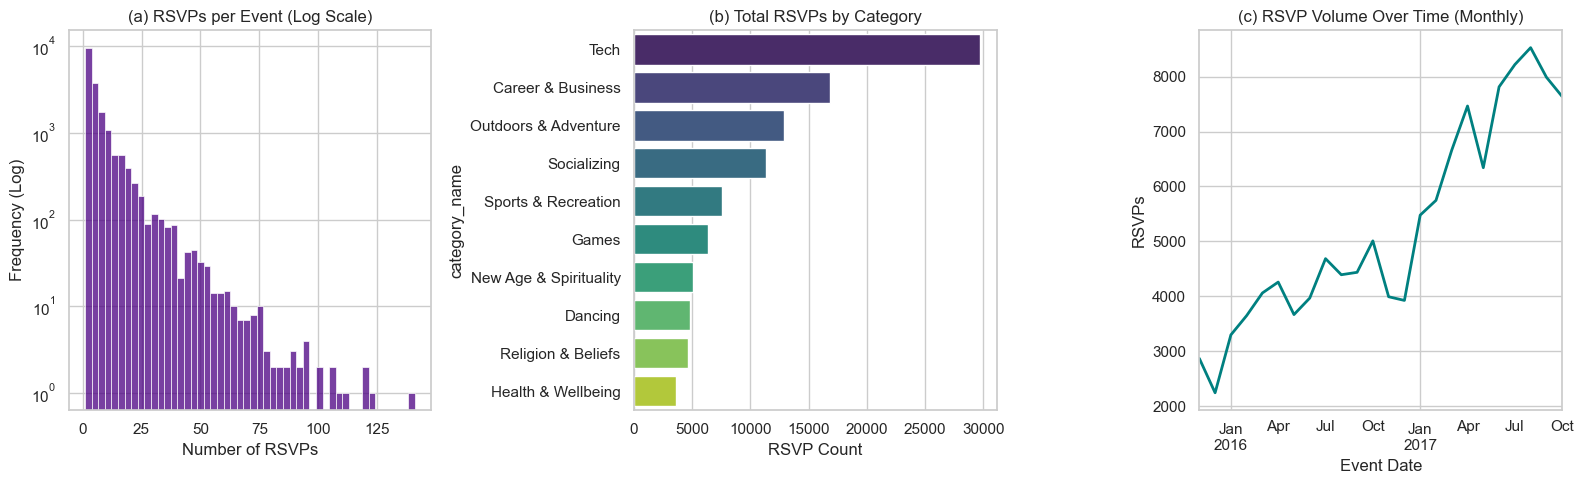


--- Event Size Statistics ---
          num_rsvps
count  18893.000000
mean       6.686551
std        9.369866
min        1.000000
50%        3.000000
75%        8.000000
90%       16.000000
95%       23.000000
99%       48.000000
max      141.000000


In [ ]:
plt.figure(figsize=(16, 5))

# --- Plot 1: Event Size Distribution ---
# How many RSVPs does a typical event get?

plt.subplot(1, 3, 1)
sns.histplot(event_sizes, x='num_rsvps',  bins=50, color='indigo')
plt.yscale('log') # Added to fix log scale definition issue within sns
plt.title('(a) RSVPs per Event (Log Scale)')
plt.xlabel('Number of RSVPs')
plt.ylabel('Frequency (Log)')

# --- Plot 2: Category Popularity ---
# Which domains drive the most interaction? 
plt.subplot(1, 3, 2)
category_counts = rsvps_master['category_name'].value_counts().head(10)
sns.barplot(y=category_counts.index, x=category_counts.values, palette='viridis')
plt.title('(b) Total RSVPs by Category')
plt.xlabel('RSVP Count')

# --- Plot 3: Temporal Event Frequency ---
# Identifying the timeline for your train/val/test split
plt.subplot(1, 3, 3)
rsvps_master.set_index('time').resample('ME').size().plot(color='teal', lw=2)
plt.title('(c) RSVP Volume Over Time (Monthly)')
plt.xlabel('Event Date')
plt.ylabel('RSVPs')

plt.tight_layout()
plt.show()

print("\n--- Event Size Statistics ---")
print(event_sizes.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

In [ ]:
mem_edges.head()

,member1,member2,weight
0,198737924,220654721,1
1,198737924,208201738,1
2,198737924,88664332,1
3,198737924,8640526,1
4,198737924,56356372,1


In [ ]:
print(mem_edges.columns.tolist())
print(mem_edges[['member1', 'member2', 'weight']].head())

['member1', 'member2', 'weight']
     member1    member2  weight
0  198737924  220654721       1
1  198737924  208201738       1
2  198737924   88664332       1
3  198737924    8640526       1
4  198737924   56356372       1


In [ ]:
import networkx as nx

subset = mem_edges.head(5000).dropna(subset=['member1', 'member2']).copy()


G_sample = nx.from_pandas_edgelist(
    subset,
    source='member1',
    target='member2',
    edge_attr='weight',
    create_using=nx.Graph()
)

assert G_sample is not None, "Graph creation returned None"
print(f"Nodes: {G_sample.number_of_nodes()}, Edges: {G_sample.number_of_edges()}")

Nodes: 3841, Edges: 5000


--- Analyzing Pre-computed Member Graph ---
Total Edges Provided: 1176368
Sample Graph Nodes: 3841
Sample Graph Edges: 5000


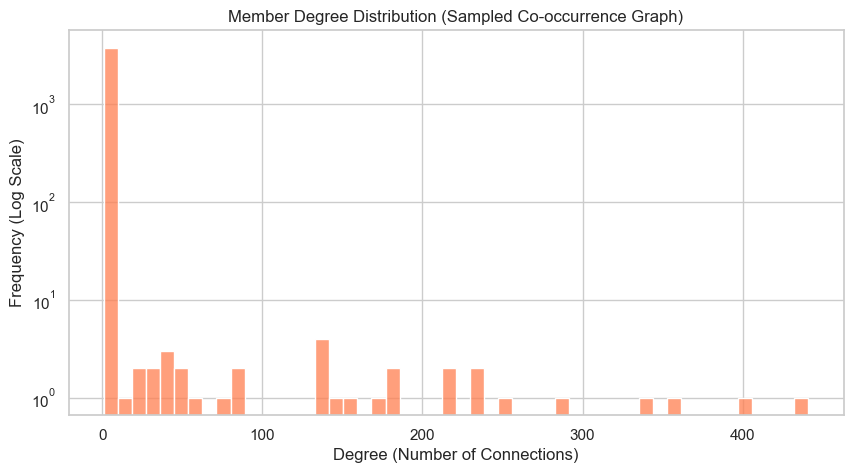


--- Edge Weight Summary ---
count    1.176368e+06
mean     1.047387e+00
std      2.501198e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.000000e+00
Name: weight, dtype: float64


In [ ]:
print("--- Analyzing Pre-computed Member Graph ---")
print(f"Total Edges Provided: {len(mem_edges)}")

# Build a graph sample to calculate structural properties efficiently
# Using top 5,000 edges to avoid memory issues and excessive computational time during EDA
subset = mem_edges.head(5000).copy().reset_index(drop=True)
G_sample = nx.from_pandas_edgelist(
    subset,
    source='member1',
    target='member2',
    edge_attr='weight',
    create_using=nx.Graph())
# Set attributes , ex btwnness centrality
bb = nx.betweenness_centrality(G_sample)
nx.set_node_attributes(G_sample, bb, 'betweenness')

print(f"Sample Graph Nodes: {G_sample.number_of_nodes()}")
print(f"Sample Graph Edges: {G_sample.number_of_edges()}")

# Calculate Degree Distribution
degrees = [d for n, d in G_sample.degree()]

plt.figure(figsize=(10, 5))
sns.histplot(degrees, bins=50, color='coral')
plt.yscale('log')
plt.title('Member Degree Distribution (Sampled Co-occurrence Graph)')
plt.xlabel('Degree (Number of Connections)')
plt.ylabel('Frequency (Log Scale)')
plt.show()

# Check weight distribution to validate edge decay viability
print("\n--- Edge Weight Summary ---")
print(mem_edges['weight'].describe())

In [ ]:
print(f"Type of graph object: {type(G_sample)}")

Type of graph object: <class 'networkx.classes.graph.Graph'>


In [309]:
events_df.head()

,event_id,group_id,time
0,243930425,26140018,2017-10-14 12:00:00
1,244208851,25604533,2017-10-15 00:15:00
2,pxlktnywnbfb,25973656,2017-10-03 23:30:00
3,244444551,18571126,2017-10-25 22:30:00
4,244257722,18571126,2017-10-18 22:30:00
